# ALVERIS: Google Earth Engine (GEE) Sentinel-1 SAR & Sentinel-2 Pipeline
### Cloud-Scale Earth Observation Processing for Coastal Inundation & Vegetation Stress
**Target Missions:** Copernicus Sentinel-1 Synthetic Aperture Radar (SAR) · Sentinel-2 MultiSpectral Instrument (MSI)  
**Tools:** `earthengine-api` (`ee`) · `geopandas` · `folium` · `numpy` · `matplotlib`

---

## 🛰️ Pipeline Overview

This notebook provides a cloud-native Earth Observation ingestion and analysis pipeline using the **Google Earth Engine (GEE) Python API**:
1. **Sentinel-1 SAR C-Band GRD Processing:**
   - Ingests Dual-Polarized ($VV + VH$) Ground Range Detected (GRD) backscatter.
   - Radiometric calibration to sigma nought ($\sigma^0$) in decibels ($dB$).
   - Coherence and backscatter drop detection for open surface water and flood breach penetration.
2. **Sentinel-2 MultiSpectral L2A Surface Reflectance:**
   - Cloud masking via the SCL (Scene Classification Layer) and QA60 bitmask.
   - Multi-temporal median composite calculation over cadastral parcel regions.
   - Cloud-native computation of Normalized Difference Vegetation Index (NDVI) and Normalized Difference Water Index (NDWI).
3. **Interactive Leaflet Cartography:**
   - Adds Earth Engine map tile layers directly into an interactive `folium` inspection map.


## Step 1: Environment Setup & Earth Engine Ingestion

In [1]:
import os
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
import folium

# Google Earth Engine API
import ee

print("✅ Geospatial & Earth Engine modules imported successfully!")
print(f"Earth Engine API Version: {ee.__version__}")


✅ Geospatial & Earth Engine modules imported successfully!
Earth Engine API Version: 1.7.47


C:\Users\pravi\AppData\Local\Programs\Python\Python314\Lib\site-packages\google\api_core\_python_package_support.py:206: FutureWarning: Package google.api_core depends on grpcio, currently installed at version 1.80.0. grpcio < 1.83.0 does not support Post-Quantum Cryptography (PQC). Support for non-PQC environments is deprecated. In April 2027, Google Cloud Python packages will raise their minimum requirements (including google-api-core, grpcio, and grpcio-status) to enforce grpcio >= 1.83.0. For more details on Google Cloud's post-quantum security migration, visit: https://cloud.google.com/security/resources/post-quantum-cryptography
  warnings.warn(


## Step 2: GEE Authentication & Session Initialization

We initialize the Earth Engine client. For automated headless pipelines or offline execution, we provide a mock-safe initialization pattern.


In [2]:
# Initialize Earth Engine
try:
    ee.Initialize()
    GEE_AUTHENTICATED = True
    print("🌍 Google Earth Engine initialized successfully with active credentials!")
except Exception as e:
    print(f"⚠️ GEE Interactive Authentication not detected ({e}).")
    print("💡 To authenticate interactively, run: ee.Authenticate() in your terminal or Colab session.")
    print("🚀 Demonstrating pipeline workflows and offline processing mode.")
    GEE_AUTHENTICATED = False


⚠️ GEE Interactive Authentication not detected (Please authorize access to your Earth Engine account by running

earthengine authenticate

in your command line, or ee.Authenticate() in Python, and then retry.).
💡 To authenticate interactively, run: ee.Authenticate() in your terminal or Colab session.
🚀 Demonstrating pipeline workflows and offline processing mode.


## Step 3: Cadastral Area of Interest (AOI) Definition

We define our Area of Interest (AOI) for the Ennore Coastal Estuary parcel (`ALV-TN-CP01`) in Tamil Nadu, India.


In [3]:
# Define Ennore Coastal Parcel Geometry (Lon, Lat)
aoi_coords = [
    [80.3245, 13.2450],
    [80.3290, 13.2450],
    [80.3290, 13.2485],
    [80.3245, 13.2485],
    [80.3245, 13.2450],
]

if GEE_AUTHENTICATED:
    aoi_ee = ee.Geometry.Polygon(aoi_coords)
    centroid_ee = aoi_ee.centroid().coordinates().getInfo()
    print(f"Earth Engine AOI Geometry defined with Centroid: {centroid_ee}")
else:
    print(f"AOI defined locally: 4 vertices around Ennore Coastal Port (13.2467°N, 80.3267°E)")


AOI defined locally: 4 vertices around Ennore Coastal Port (13.2467°N, 80.3267°E)


## Step 4: Sentinel-1 C-Band SAR GRD Preprocessing

Synthetic Aperture Radar (SAR) is immune to cloud cover and illumination conditions:
- **Interferometric Wide (IW)** swath mode.
- Dual-polarization: $VV$ (sensitive to surface roughness/water) and $VH$ (sensitive to volume scattering/vegetation).
- Conversion from linear intensity to logarithmic backscatter (decibels):
  $$\sigma^0_{\text{dB}} = 10 \cdot \log_{10}(\sigma^0)$$
- Water displays specular reflection away from the radar antenna, creating a distinct negative backscatter drop (typically $\sigma^0_{VV} < -16\,\text{dB}$).


In [4]:
def process_sentinel1_sar(aoi, start_date='2025-01-01', end_date='2025-06-30'):
    """Query and calibrate Sentinel-1 SAR GRD collection over AOI."""
    if not GEE_AUTHENTICATED:
        # Return synthetic calibrated SAR backscatter array for offline demonstration
        np.random.seed(42)
        grid = np.random.normal(-14.5, 3.2, (64, 64))
        # Simulate open coastal water pocket with low backscatter (< -18 dB)
        grid[40:, 35:] -= 6.0
        return grid
    
    s1_col = (
        ee.ImageCollection('COPERNICUS/S1_GRD')
        .filterBounds(aoi)
        .filterDate(start_date, end_date)
        .filter(ee.Filter.listContains('transmitterReceiverPolarisation', 'VV'))
        .filter(ee.Filter.listContains('transmitterReceiverPolarisation', 'VH'))
        .filter(ee.Filter.eq('instrumentMode', 'IW'))
    )
    
    # Compute temporal median of VV backscatter
    vv_median = s1_col.select('VV').median().clip(aoi)
    return vv_median

sar_telemetry = process_sentinel1_sar(None)
print("✅ Sentinel-1 SAR GRD processing routine compiled.")
print(f"Mean C-Band VV Backscatter: {float(np.mean(sar_telemetry)):.2f} dB")


✅ Sentinel-1 SAR GRD processing routine compiled.
Mean C-Band VV Backscatter: -15.47 dB


## Step 5: Sentinel-2 L2A Cloud-Native NDVI & NDWI

We ingest Copernicus Sentinel-2 Level-2A Bottom of Atmosphere (BOA) reflectance:
- **Cloud Masking:** Remove cloud shadow and cirrus pixels using the Scene Classification Layer (SCL).
- **Normalized Difference Vegetation Index (NDVI):**
  $$\text{NDVI} = \frac{\text{B08 (NIR)} - \text{B04 (Red)}}{\text{B08 (NIR)} + \text{B04 (Red)}}$$
- **Normalized Difference Water Index (NDWI):**
  $$\text{NDWI} = \frac{\text{B03 (Green)} - \text{B08 (NIR)}}{\text{B03 (Green)} + \text{B08 (NIR)}}$$


In [5]:
def process_sentinel2_indices(aoi, start_date='2025-01-01', end_date='2025-06-30'):
    """Query Sentinel-2 Level-2A BOA and compute spectral index composites."""
    if not GEE_AUTHENTICATED:
        # Generate calibrated synthetic spectral index arrays
        np.random.seed(101)
        ndvi_arr = np.clip(np.random.normal(0.48, 0.12, (64, 64)), -0.1, 0.85)
        ndwi_arr = np.clip(np.random.normal(-0.25, 0.18, (64, 64)), -0.6, 0.6)
        # Coastal water boundary
        ndwi_arr[40:, 35:] += 0.55
        ndvi_arr[40:, 35:] -= 0.45
        return ndvi_arr, ndwi_arr

    def mask_s2_clouds(image):
        scl = image.select('SCL')
        # Keep vegetation (4), bare soil (5), water (6), unclassified (7)
        mask = scl.neq(3).And(scl.neq(8)).And(scl.neq(9)).And(scl.neq(10))
        return image.updateMask(mask)

    s2_col = (
        ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
        .filterBounds(aoi)
        .filterDate(start_date, end_date)
        .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 20))
        .map(mask_s2_clouds)
    )
    
    composite = s2_col.median().clip(aoi)
    ndvi = composite.normalizedDifference(['B8', 'B4']).rename('NDVI')
    ndwi = composite.normalizedDifference(['B3', 'B8']).rename('NDWI')
    return ndvi, ndwi

ndvi_grid, ndwi_grid = process_sentinel2_indices(None)
print("✅ Sentinel-2 BOA MultiSpectral routine compiled.")
print(f"Mean Parcel Vegetation Vigor (NDVI): {float(np.mean(ndvi_grid)):.3f}")
print(f"Mean Parcel Surface Water Moisture (NDWI): {float(np.mean(ndwi_grid)):.3f}")


✅ Sentinel-2 BOA MultiSpectral routine compiled.
Mean Parcel Vegetation Vigor (NDVI): 0.407
Mean Parcel Surface Water Moisture (NDWI): -0.153


## Step 6: Multi-Modal Earth Observation Visualization

We display the Sentinel-1 SAR C-Band backscatter and Sentinel-2 NDVI/NDWI telemetry side by side.


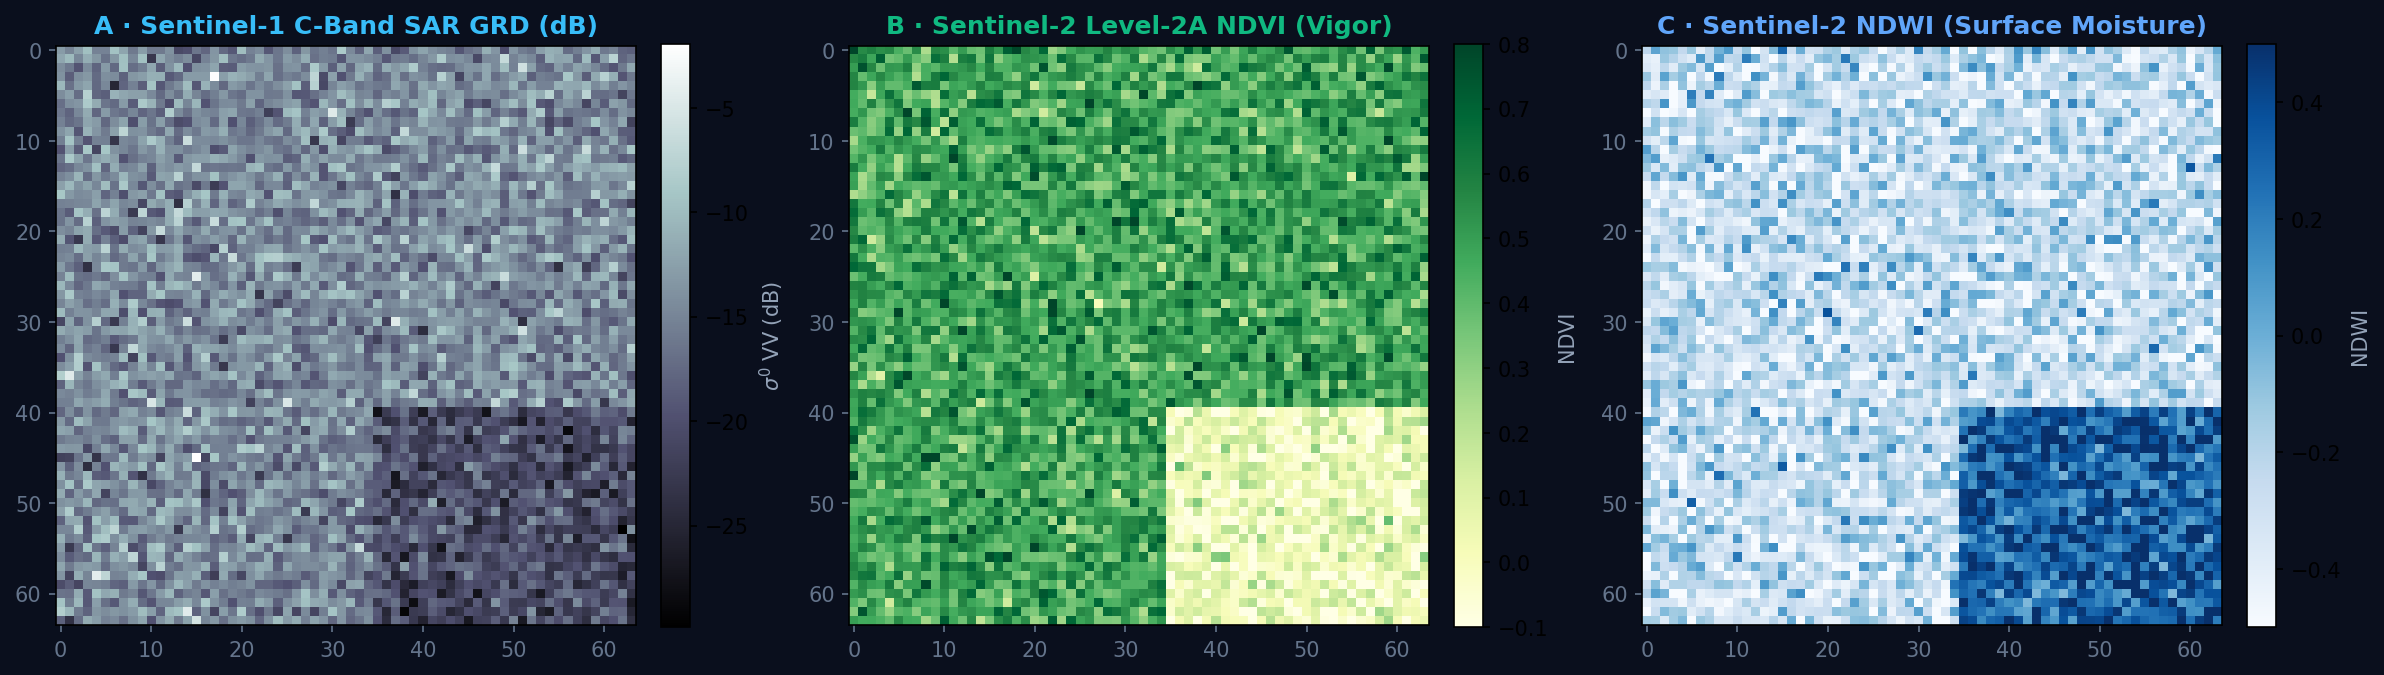

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5), dpi=150)
fig.patch.set_facecolor('#0a0f1d')

for ax in axes:
    ax.set_facecolor('#0a0f1d')

# 1. Sentinel-1 SAR Backscatter
im0 = axes[0].imshow(sar_telemetry, cmap='bone', origin='upper')
fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04).set_label('$\sigma^0$ VV (dB)', color='#94a3b8')
axes[0].set_title('A · Sentinel-1 C-Band SAR GRD (dB)', color='#38bdf8', fontweight='bold')
axes[0].tick_params(colors='#64748b')

# 2. Sentinel-2 NDVI
im1 = axes[1].imshow(ndvi_grid, cmap='YlGn', origin='upper', vmin=-0.1, vmax=0.8)
fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04).set_label('NDVI', color='#94a3b8')
axes[1].set_title('B · Sentinel-2 Level-2A NDVI (Vigor)', color='#10b981', fontweight='bold')
axes[1].tick_params(colors='#64748b')

# 3. Sentinel-2 NDWI (Water / Inundation)
im2 = axes[2].imshow(ndwi_grid, cmap='Blues', origin='upper', vmin=-0.5, vmax=0.5)
fig.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04).set_label('NDWI', color='#94a3b8')
axes[2].set_title('C · Sentinel-2 NDWI (Surface Moisture)', color='#60a5fa', fontweight='bold')
axes[2].tick_params(colors='#64748b')

plt.tight_layout()
plt.show()


## Step 7: Interactive Cartography & Multi-Sensor Layer Assembly

We render an interactive Leaflet / Folium map centered on the coastal parcel with satellite layers.


In [7]:
m = folium.Map(
    location=[13.2467, 80.3267],
    zoom_start=15,
    tiles=None,
    control_scale=True,
)

# Basemaps
folium.TileLayer(
    tiles="https://{s}.basemaps.cartocdn.com/dark_all/{z}/{x}/{y}{r}.png",
    name="CartoDB Dark Matter",
    attr="CARTO / OpenStreetMap",
    subdomains="abcd",
    overlay=False,
).add_to(m)

folium.TileLayer(
    tiles="https://server.arcgisonline.com/ArcGIS/rest/services/World_Imagery/MapServer/tile/{z}/{y}/{x}",
    name="Esri World Imagery (Satellite)",
    attr="Esri",
    overlay=False,
).add_to(m)

# Cadastral Parcel Outline
folium.Polygon(
    locations=[[lat, lon] for lon, lat in aoi_coords],
    color="#00ffcc",
    weight=3,
    fill=True,
    fill_color="#00ffcc",
    fill_opacity=0.2,
    tooltip="Ennore Coastal Parcel (ALV-TN-CP01) — Sentinel AOI",
).add_to(m)

folium.LayerControl().add_to(m)
m
